<a href="https://colab.research.google.com/github/lukmannm/data-science-2026/blob/main/Pertemuan4_Lukman__240401010181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Load & Inspect Dataset

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

Dataset Iris dimuat menggunakan seaborn.load_dataset().

## 2. Statistik Deskriptif Lengkap

In [16]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')    # Rata-rata nilai
    print(f'  Median   : {col.median():.3f}')  # Nilai tengah
    print(f'  Std Dev  : {col.std():.3f}')     # Seberapa menyebar data dari mean
    print(f'  Skewness : {col.skew():.3f}')    # Kemiringan distribusi (0 = simetris)
    print(f'  Kurtosis : {col.kurt():.3f}')    # Ketajaman puncak distribusi


=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Skewness : -0.103
  Kurtosis : -1.341


Menghitung statistik dasar untuk setiap kolom numerik.

## 3. Analisis Distribusi (Histogram + KDE)

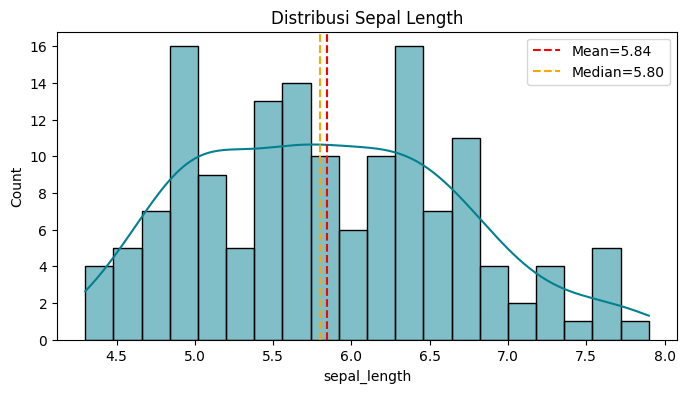

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

# Histogram + kurva KDE distribusi sepal_length
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Garis mean dan median sebagai referensi pusat data
ax.axvline(df['sepal_length'].mean(),
           color='red', linestyle='--',
           label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(),
           color='orange', linestyle='--',
           label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

Histogram dengan kurva KDE untuk melihat distribusi data sepal_length, dilengkapi garis mean (merah) dan median (oranye) untuk membandingkan pusat data.

## 4. Boxplot per Spesies

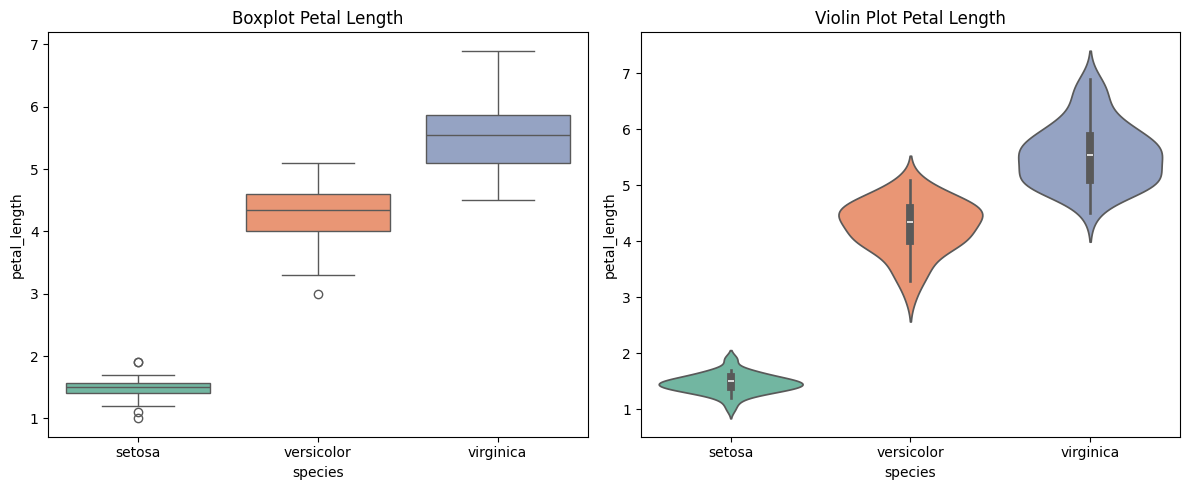

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: ringkasan statistik per spesies (median, IQR, outlier)
sns.boxplot(
    data=df, x='species', y='petal_length',
    hue='species', palette='Set2', legend=False, ax=axes[0]
)
axes[0].set_title('Boxplot Petal Length')

# Violin plot: bentuk distribusi data per spesies
sns.violinplot(
    data=df, x='species', y='petal_length',
    hue='species', palette='Set2', inner='box', legend=False, ax=axes[1]
)
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

Membandingkan distribusi petal_length antar spesies menggunakan dua jenis visualisasi, boxplot untuk melihat outlier dan ringkasan statistik, violin plot untuk melihat bentuk distribusi datanya.

## 5. Matriks Korelasi Pearson

In [12]:
# Hitung korelasi Pearson antar fitur numerik (kolom species dikeluarkan)
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

# Sembunyikan segitiga atas agar tidak ada pasangan duplikat
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

# Temukan pasangan fitur dengan korelasi tertinggi
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Menghitung korelasi Pearson antar fitur numerik untuk melihat seberapa kuat hubungan linear antar variabel. Korelasi tertinggi juga ditampilkan secara otomatis.

## 6. Scatter Plot & Heatmap

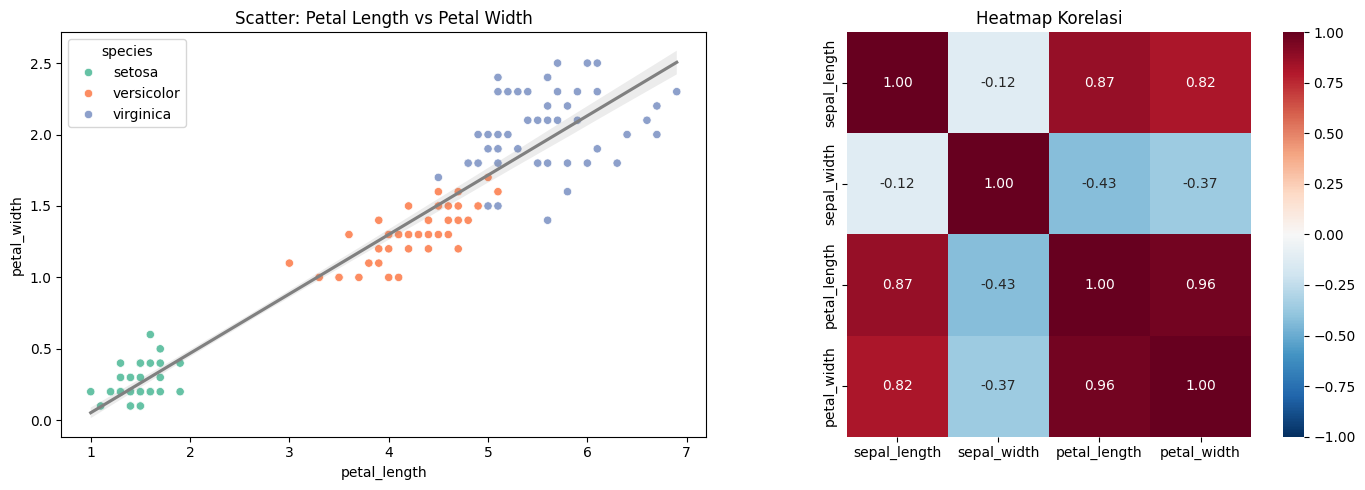

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: hubungan petal_length vs petal_width per spesies
sns.scatterplot(
    data=df, x='petal_length', y='petal_width',
    hue='species', palette='Set2', ax=axes[0]
)
# Garis regresi keseluruhan (tanpa titik scatter)
sns.regplot(
    data=df, x='petal_length', y='petal_width',
    scatter=False, color='gray', ax=axes[0]
)
axes[0].set_title('Scatter: Petal Length vs Petal Width')

# Heatmap: nilai korelasi antar semua fitur numerik
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, square=True, ax=axes[1]
)
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Visualisasi hubungan antar fitur, scatter plot untuk melihat pola per spesies antara petal_length dan petal_width, serta heatmap untuk melihat nilai korelasi semua fitur sekaligus